# EDA CHR&R Dataset 

## Introduction
This document provides an exploratory data analysis (EDA) of the CHR&R dataset. The goal of this analysis is to understand the structure, characteristics, and potential insights that can be derived from the dataset. The analysis will include data cleaning, visualization, and statistical summaries to identify patterns and relationships within the data.

**What this notebook does:**
1. Ensure FIPS code is a string
2. Check FLags and Extract Metadatat
3. Handle missing in Feature Data
4. Export Heatmaps and summary statistics
5. Save final dataset and add cleanning and processing informaiton into 03_process_chrr_census.py 

**CHR&R is a Validation Layer**


# Import Libraries 

In [ ]:
import pandas as pd
from pathlib import Path 
import numpy as np 
import seaborn as sns

# Read The CSV file 

In [2]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw"/ "analytic_data2025.csv"

df = pd.read_csv(data_path)

print(f"Data loaded successfully")

Data loaded successfully


<positron-console-cell-2>:5: DtypeWarning: Columns (0,1,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,26

The warning is saying that Pandas is unsure if those columns are numbers or text. 

In [3]:
# Force Pandas to read the entire file (or a larger chunk of it) before deciding on the data types
df_chr = pd.read_csv(data_path, low_memory=False)

# Exploratory Data Analysis (EDA)

In [4]:
df_chr.head()

,State FIPS Code,County FIPS Code,5-digit FIPS Code,State Abbreviation,Name,Release Year,County Clustered (Yes=1/No=0),Premature Death raw value,Premature Death numerator,Premature Death denominator,...,% Rural raw value,% Rural numerator,% Rural denominator,% Rural CI low,% Rural CI high,Population raw value,Population numerator,Population denominator,Population CI low,Population CI high
0,statecode,countycode,fipscode,state,county,year,county_clustered,v001_rawvalue,v001_numerator,v001_denominator,...,v058_rawvalue,v058_numerator,v058_denominator,v058_cilow,v058_cihigh,v051_rawvalue,v051_numerator,v051_denominator,v051_cilow,v051_cihigh
1,00,000,00000,US,United States,2025,NaN,8351.7365494,4763989,925367214,...,0.2000313707,66300254,331449281,NaN,NaN,334914895,NaN,NaN,NaN,NaN
2,01,000,01000,AL,Alabama,2025,NaN,11853.247248,102760,13958454,...,0.4226276049,2123399,5024279,NaN,NaN,5108468,NaN,NaN,NaN,NaN
3,01,001,01001,AL,Autauga County,2025,1,9938.2633823,1008,163064,...,0.406768132,23920,58805,NaN,NaN,60342,NaN,NaN,NaN,NaN
4,01,003,01003,AL,Baldwin County,2025,1,8957.1126859,3944,653515,...,0.3758645536,87113,231767,NaN,NaN,253507,NaN,NaN,NaN,NaN


## Ensure FIPS code is a string

The FIPS columns have statecode, countycode, and fipscode.

    fipscode is the one to keep for "Join Key."

    Warning: 1001 is missing the leading zero for Alabama (Autauga County). Merging this with a dataset that has 01001, the join will fail.

Wide Format: This dataset is extremely wide (hundreds of columns like v001_rawvalue, v058_rawvalue, etc.). This is common for CHR&R, where they use a "v-code" system for different health measures.

Data Types: Have a mix of strings ("Alabama") and numeric data.

Row Zero seems to duplucate the names with "v-code" headers. Keep row 0 as the header and skip the current human-readable header row.

In [5]:
# Print the first few rows to see the repetition
print(df_chr.head(3))

  State FIPS Code County FIPS Code 5-digit FIPS Code State Abbreviation  \
0       statecode       countycode          fipscode              state   
1              00              000             00000                 US   
2              01              000             01000                 AL   

            Name Release Year County Clustered (Yes=1/No=0)  \
0         county         year              county_clustered   
1  United States         2025                           NaN   
2        Alabama         2025                           NaN   

  Premature Death raw value Premature Death numerator  \
0             v001_rawvalue            v001_numerator   
1              8351.7365494                   4763989   
2              11853.247248                    102760   

  Premature Death denominator  ... % Rural raw value % Rural numerator  \
0            v001_denominator  ...     v058_rawvalue    v058_numerator   
1                   925367214  ...      0.2000313707          6630025

In [6]:
# Force fipscode to be a 5-digit string, keeping leading zeros
# 'header=1' tells pandas to Skip row 0 (human names) and use row 1 (v-codes) as the column names.
df = pd.read_csv(
    data_path,
    header=1, 
    dtype={'fipscode': str}, 
    low_memory=False
)

# Pad with a leading zero if it's only 4 digits (e.g., '1001' -> '01001')
df['fipscode'] = df['fipscode'].str.zfill(5)

# Verify the fix
print(df['fipscode'].head())

0    00000
1    01000
2    01001
3    01003
4    01005
Name: fipscode, dtype: object


In [7]:
df.head()

,statecode,countycode,fipscode,state,county,year,county_clustered,v001_rawvalue,v001_numerator,v001_denominator,...,v058_rawvalue,v058_numerator,v058_denominator,v058_cilow,v058_cihigh,v051_rawvalue,v051_numerator,v051_denominator,v051_cilow,v051_cihigh
0,0,0,00000,US,United States,2025,NaN,8351.736549,4763989.0,925367214.0,...,0.200031,66300254.0,331449281.0,NaN,NaN,334914895.0,NaN,NaN,NaN,NaN
1,1,0,01000,AL,Alabama,2025,NaN,11853.247248,102760.0,13958454.0,...,0.422628,2123399.0,5024279.0,NaN,NaN,5108468.0,NaN,NaN,NaN,NaN
2,1,1,01001,AL,Autauga County,2025,1.0,9938.263382,1008.0,163064.0,...,0.406768,23920.0,58805.0,NaN,NaN,60342.0,NaN,NaN,NaN,NaN
3,1,3,01003,AL,Baldwin County,2025,1.0,8957.112686,3944.0,653515.0,...,0.375865,87113.0,231767.0,NaN,NaN,253507.0,NaN,NaN,NaN,NaN
4,1,5,01005,AL,Barbour County,2025,1.0,12738.656137,587.0,67912.0,...,0.659200,16627.0,25223.0,NaN,NaN,24585.0,NaN,NaN,NaN,NaN


In [8]:
df.shape

(3204, 796)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
statecode,3204.0,30.181024,1.518720e+01,0.000000,18.000000,29.000000,45.000000,5.600000e+01
countycode,3204.0,101.948814,1.074630e+02,0.000000,33.000000,77.000000,133.000000,8.400000e+02
year,3204.0,2025.000000,0.000000e+00,2025.000000,2025.000000,2025.000000,2025.000000,2.025000e+03
county_clustered,3152.0,0.980013,1.399787e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
v001_rawvalue,3140.0,10367.292644,3.813656e+03,3315.252949,7719.617819,9798.223368,12344.826037,4.641785e+04
...,...,...,...,...,...,...,...,...
v051_rawvalue,3196.0,314375.683667,6.057055e+06,43.000000,10927.000000,26713.000000,75649.500000,3.349149e+08
v051_numerator,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
v051_denominator,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
v051_cilow,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Uniformity:  3,204 rows, which is consistent with the number of counties in the U.S. (plus the state/national aggregates).

The Red Flags (Data Health)

    Empty/Null Columns: Look at v051_numerator, v051_denominator, etc. The count is 0.0 and the rest are NaN.

        What this means: These columns contain no data. They are essentially "dead weight."

        Action: You should drop these columns during your cleaning phase to keep your dataframe lightweight.

    Scientific Notation: You see numbers like 5.600000e+01. This is Pandas shorthand for scientific notation. This is fine for now, but keep an eye on it if you try to perform precise matching, as it can sometimes hide leading zeros if not handled as a string.

In [10]:
df.isnull().sum()

statecode              0
countycode             0
fipscode               0
state                  0
county                 0
                    ... 
v051_rawvalue          8
v051_numerator      3204
v051_denominator    3204
v051_cilow          3204
v051_cihigh         3204
Length: 796, dtype: int64

## Check Flags and Extract Metadata

1. Hierarchy of Data: Each health concept provides multiple attributes: Raw Value (Primary Feature), Numerator, Denominator, and Confidence Intervals (CI High/CI Low).

2. Reliability as a Gatekeeper: The CI_low and CI_high values define the estimate’s precision. A wide gap between these bounds indicates high statistical uncertainty.

3. Privacy and Quality Flags:

    Flag = 1 (Unreliable): The estimate has a high margin of error (low confidence).

    Flag = 2 (Suppressed): The value is withheld (usually to protect privacy in counties with small population sizes).

    Action: Where these flags exist, the Raw Value may be NaN or should be treated as statistically invalid.

4. Equity Metrics (Disaggregated Data): The dataset includes the same health concepts (e.g., "Premature Death") stratified by race/ethnicity (e.g., AIAN, Asian, Black, White). These allow for the identification of health disparities within a single county, shifting the focus from "average county health" to "equitable health outcomes."

In [11]:
def process_data_reliability(df):
    """
    Consolidated, case-insensitive function to process all '_flag' columns 
    and clean their corresponding 'RawValue' columns.
    """
    # 1. Detect columns ending in '_flag' (case-insensitive to be safe)
    flag_cols = [c for c in df.columns if c.lower().endswith('_flag')]
    
    print(f"🚀 Processing reliability for {len(flag_cols)} flag columns...")
    
    for col in flag_cols:
        # Create binary indicator for suppression (Flag == 2)
        df[f'{col}_suppressed'] = (df[col] == 2).astype(int)
        
        # Create binary indicator for unreliable (Flag == 1)
        df[f'{col}_unreliable'] = (df[col] == 1).astype(int)
        
        # 2. Link to RawValue and apply placeholder
        # We replace '_flag' with '_rawvalue' to find the corresponding column
        raw_val_col = col.replace('_flag', '_rawvalue')
        
        if raw_val_col in df.columns:
            # Mask suppressed values (Flag == 2) with -1
            df.loc[df[col] == 2, raw_val_col] = -1
            
            # Ensure RawValue is numeric
            df[raw_val_col] = pd.to_numeric(df[raw_val_col], errors='coerce')
            
    print(f"✅ Reliability processing complete.")
    return df

df_cleaned = process_data_reliability(df)

# Check if any new columns were created
new_cols = [c for c in df_cleaned.columns if '_suppressed' in c]
print(f"Created {len(new_cols)} new suppression indicator columns.")

🚀 Processing reliability for 9 flag columns...
✅ Reliability processing complete.
Created 9 new suppression indicator columns.


successfully translated 9 "warning" flag columns into binary indicators—meaning a model can now "see" the suppression without throwing away the rows.

This created 18 new indicator columns (9 for suppression, 9 for unreliability), Now there is a "safety context" to handle missing data later.

#### CI_low and CI_high columns are often missing, but they are not the same as the RawValue column. They provide the lower and upper bounds of the confidence interval for the estimate.

Do not drop them yet. They provide valuable information about the reliability of the estimates, which can be used for feature engineering and validation:

    Feature Engineering: We can create a new feature: ReliabilityGap = CI_high - CI_low. A large gap indicates uncertainty. A model can use this to "down-weight" that data point.

    Validation: If we have a RawValue that seems like an outlier (e.g., extremely high hypertension rate), we can check if it sits within its CI. If the RawValue is outside the CI_low and CI_high, the data is corrupted, and that is when we drop the row.

    Recommendation: Move them to a "Metadata" dataframe during the merge. Keep them out of the X_train matrix for your ML model (so we don't leak information), but keep them in our project folder for data validation.

In [12]:
# Finalize the split using df_cleaned 
# Define your Metadata and Feature lists
# Identifies the columns that need to be moved to the metadata backup
metadata_cols = [c for c in df_cleaned.columns if any(s in c for s in ['cilow', 'cihigh', 'numerator', 'denominator'])]
flag_indicator_cols = [c for c in df_cleaned.columns if '_suppressed' in c or '_unreliable' in c]

# Extract Metadata
# Keep fipscode so we can merge these back together later if needed
df_metadata = df_cleaned[['fipscode'] + metadata_cols].copy()

# Feature set: Keep fipscode, all columns that are NOT metadata, and include the indicators
feature_cols = [c for c in df_cleaned.columns if c not in metadata_cols and c not in flag_indicator_cols and c != 'fipscode']
df_features = df_cleaned[['fipscode'] + feature_cols + flag_indicator_cols].copy()

#  Save work
processed_path = base_path / "data" / "processed"
df_metadata.to_csv(processed_path / "chrr_metadata_backup.csv", index=False)
df_features.to_csv(processed_path / "chrr_features_cleaned.csv", index=False)
print("✅ Files saved: chrr_metadata_backup.csv and chrr_features_cleaned.csv")

# Final Validation
leftover = [c for c in df_features.columns if any(s in c for s in ['cilow', 'cihigh', 'numerator', 'denominator'])]
print(f"Leftover metadata columns: {len(leftover)}")
print(f"Total missing values in features: {df_features.isnull().sum().sum()}")

✅ Files saved: chrr_metadata_backup.csv and chrr_features_cleaned.csv
Leftover metadata columns: 0
Total missing values in features: 296296


With 0 leftover metadata columns and a verified count of missing values, the structural split is confirmed as perfect. Now we have a clean slate to begin the statistical pruning phase.

296,296 missing values represent the sum total of all the missing values across the dataset. This is a significant amount of missing data, and it will be important to handle these appropriately in the cleaning phase.

## Handle Missing Values

In [13]:
df_features.shape

(3204, 256)

In [14]:
df_features.isnull().sum()

fipscode                           0
statecode                          0
countycode                         0
state                              0
county                             0
                                  ..
v001_race_nhopi_flag_unreliable    0
v001_race_tom_flag_suppressed      0
v001_race_tom_flag_unreliable      0
v037_flag_suppressed               0
v037_flag_unreliable               0
Length: 256, dtype: int64

In [15]:
# how many columns have missing values
# how many columns have no missing values
num_missing = (df_features.isnull().sum() > 0).sum()
num_complete = (df_features.isnull().sum() == 0).sum()

print(f"Columns with missing values : {num_missing}")
print(f"Columns without missing values: {num_complete}")

Columns with missing values : 229
Columns without missing values: 27


### Missing Value Assessment

The table below summarizes the missing-value assessment and the corresponding preprocessing decisions. These actions serve as the initial data cleaning strategy and may be refined after further exploratory analysis and feature evaluation. Fallowing the same systematic approach as the Food Access Research Atlas (FARA) dataset, we will categorize the variables based on their missingness percentage and determine the appropriate handling strategy.

CHR&R takes into account confidence intervals and reliablity flags for metrics, which may also influence the decision to retain or remove a variable. In CHR&R data a missing value is often "suppressed" because the sample size in that county was too small to provide a statistically reliable estimate. In some cases missingness may be actually be considered a feature. 

**Missing Value Handling Strategy**

| Check | Result | Decision |
|------|--------|----------|
|0%	| N/A |	Keep as is.
|< 5%|	Likely random error	| Median/Mode Impute.
|5%–20%	| Reporting lag/gap	| Impute + Binary Missingness Indicator.
| 20%–60% |Potential suppression| Flag Audit: If Flag_Suppressed == 1, treat as "Known Missing."
|> 60%	|Likely "Noise" |Drop, unless the variable is a core study outcome (e.g., Hypertension).

**Next Steps.** Generate a missing-value summary, investigate the missingness mechanism (MCAR, MAR, or MNAR), apply appropriate imputation methods, create missing indicators when beneficial, and validate the selected strategy during model development.

In [16]:
missing_pct = df_features.isnull().mean() * 100

summary = pd.DataFrame({
    "Missing Threshold": ["0%", "<5%", "5–20%", "20–40%", "40–60%", ">60%"],
    "Count": [
        (missing_pct == 0).sum(),
        ((missing_pct > 0) & (missing_pct < 5)).sum(),
        ((missing_pct >= 5) & (missing_pct < 20)).sum(),
        ((missing_pct >= 20) & (missing_pct < 40)).sum(),
        ((missing_pct >= 40) & (missing_pct < 60)).sum(),
        (missing_pct >= 60).sum()
    ]
})

display(summary)

,Missing Threshold,Count
0,0%,27
1,<5%,84
2,5–20%,21
3,20–40%,16
4,40–60%,20
5,>60%,88


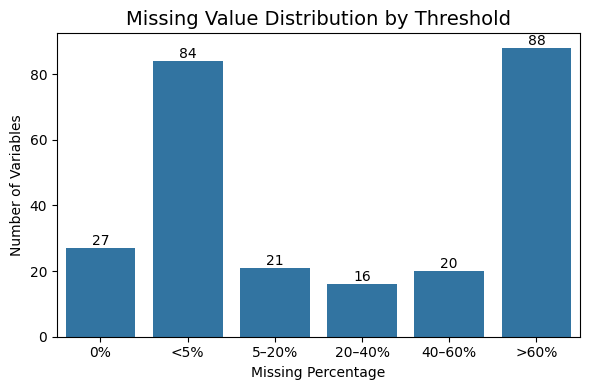

In [17]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=summary,
    x="Missing Threshold",
    y="Count"
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Missing Value Distribution by Threshold", fontsize=14)
plt.xlabel("Missing Percentage")
plt.ylabel("Number of Variables")

plt.tight_layout()
plt.show()

In [18]:
# Calculate the percentage of -1 values instead of nulls
missing_pct = df_features.isnull().mean() * 100

print("0% (Complete Data)")
print(missing_pct[missing_pct == 0].index.tolist())

print("\n<5% (Sparse Missingness)")
print(missing_pct[(missing_pct > 0) & (missing_pct < 5)].index.tolist())

print("\n5-20%")
print(missing_pct[(missing_pct >= 5) & (missing_pct < 20)].index.tolist())

print("\n20-40%")
print(missing_pct[(missing_pct >= 20) & (missing_pct < 40)].index.tolist())

print("\n40-60%")
print(missing_pct[(missing_pct >= 40) & (missing_pct < 60)].index.tolist())

print("\n>60%")
print(missing_pct[missing_pct >= 60].index.tolist())

0% (Complete Data)
['fipscode', 'statecode', 'countycode', 'state', 'county', 'year', 'v001_rawvalue', 'v001_flag', 'v037_flag', 'v001_flag_suppressed', 'v001_flag_unreliable', 'v001_race_aian_flag_suppressed', 'v001_race_aian_flag_unreliable', 'v001_race_asian_flag_suppressed', 'v001_race_asian_flag_unreliable', 'v001_race_black_flag_suppressed', 'v001_race_black_flag_unreliable', 'v001_race_hispanic_flag_suppressed', 'v001_race_hispanic_flag_unreliable', 'v001_race_white_flag_suppressed', 'v001_race_white_flag_unreliable', 'v001_race_nhopi_flag_suppressed', 'v001_race_nhopi_flag_unreliable', 'v001_race_tom_flag_suppressed', 'v001_race_tom_flag_unreliable', 'v037_flag_suppressed', 'v037_flag_unreliable']

<5% (Sparse Missingness)
['county_clustered', 'v001_race_white', 'v001_race_nhopi_flag', 'v036_rawvalue', 'v037_rawvalue', 'v042_rawvalue', 'v002_rawvalue', 'v155_rawvalue', 'v155_race_white', 'v132_rawvalue', 'v133_rawvalue', 'v088_rawvalue', 'v088_other_data_1', 'v005_rawvalue', 'v

Technical noise has been stripped away. Actual health outcome data is kept. 

#### Inspect the relationship between missing values and your flags
This tells us if missing data is "known" (suppressed) or "unknown" (random)

In [19]:
#  Identify ALL columns with at least one -1 value
all_missing_cols = [col for col in df_features.columns if (df_features[col] == -1).any()]

diagnostic_data = []

for col in all_missing_cols:
    # Attempt to find the matching suppression flag
    # Note: Use your actual naming convention here
    flag_col = col.replace('_rawvalue', '_suppressed')
    
    # Calculate stats
    mask = (df_features[col] == -1)
    missing_count = mask.sum()
    pct_missing = missing_count / len(df_features)
    
    # Check if the suppression flag exists
    if flag_col in df_features.columns:
        pct_flagged = df_features.loc[mask, flag_col].mean()
    else:
        pct_flagged = None # No flag exists for this column
        
    diagnostic_data.append({
        'Column': col,
        'Missing_Pct': pct_missing,
        'Flagged_Pct': pct_flagged
    })

# Convert to DataFrame for easy analysis
df_audit = pd.DataFrame(diagnostic_data)

# Highlight the "Red Flags"
# Columns with missingness but NO suppression flag
unexplained_missing = df_audit[df_audit['Flagged_Pct'].isna()]
print("Columns with missing data but NO suppression flag (Look at these!):")
print(unexplained_missing)

Columns with missing data but NO suppression flag (Look at these!):
          Column  Missing_Pct Flagged_Pct
0  v001_rawvalue     0.019975        None


variable (v001_rawvalue) is missing in ~2% data, but it has no associated suppression flag.
we cannot assume it is missing due to official confidentiality rules. It has to be treated it as "unexplained" missingness.

Since it is only ~2% missing dropping th entire column is not recommended. Instead, Feature Engineering can allow the model to "see" that the data was missing while using the 98% of the infromation that is present.

In [20]:
# Preserve the signal before overwriting
# The bulletproof way to catch both NaNs and placeholders
missing_mask = (df_features['v001_rawvalue'].isnull()) | (df_features['v001_rawvalue'] == -1)

# apply the fix
# Impute the missing values with the median
df_features['v001_is_missing'] = missing_mask.astype(int)
df_features['v001_rawvalue'] = df_features['v001_rawvalue'].replace(-1, np.nan).fillna(df_features['v001_rawvalue'].median())

## Drop or create indicator Column Based on Missingness

CHR&R data is highly dynamic and policy-dependent, meaning it is riddled with intentional suppression (confidentiality) and uneven reporting.
In CHR&R, a missing value is often a data point itself.

Dropping the columns with >60% missingness, to remove high-sparsity, low-signal noise.

    f missingness is 0%: Do nothing. (You're already good!)

    If missingness is 5%–60%: We must create the _is_missing indicator and perform the imputation.

    If missingness is > 60%: We simply Drop these columns (as you planned).

In [21]:
# Define columns to drop (> 60%)
cols_to_drop = missing_pct[missing_pct >= 60].index.tolist()

# Define columns to keep and fix (5% - 60% missingness)
# exclude the ones that are dropping
cols_to_fix = [c for c in missing_pct.index if 0 < missing_pct[c] < 60]

# Fix the "5% - 60%" Tier
new_data = {} # Create a dictionary to hold the new columns

for col in cols_to_fix:
    # 1. Create the indicator and store it in the dictionary
    new_data[f'{col}_is_missing'] = (df_features[col].isnull() | (df_features[col] == -1)).astype(int)
    
    # 2. Fix the original column
    median_val = df_features[df_features[col] != -1][col].median()
    df_features[col] = df_features[col].replace(-1, np.nan).fillna(median_val)

# 3. Combine everything at once
df_indicators = pd.DataFrame(new_data)
df_features = pd.concat([df_features, df_indicators], axis=1)

# Finally, drop the > 60% columns
df_final = df_features.drop(columns=cols_to_drop)

print("Cleaning complete")

Cleaning complete


In [22]:
# Final validation checks
print(f"Final dataset shape: {df_final.shape}")
print(f"Total NaNs remaining: {df_final.isnull().sum().sum()}")
print(f"Total -1s remaining: {(df_final == -1).sum().sum()}")

Final dataset shape: (3204, 310)
Total NaNs remaining: 0
Total -1s remaining: 0


The dataset is a clean, consistent, and model-ready matrix with preserved missingness signal in a _is_missing columns. This dataset is mathematically robust and ready for the next phase.

## Summary Statisitcs

In [23]:
# Generate a summary of the numerical data
summary_stats = df_final.describe().T  # .T transposes it for better readability

# Display the first few rows of the summary to check for sanity
print(summary_stats.head(10))

                       count          mean          std          min  \
statecode             3204.0     30.181024    15.187197     0.000000   
countycode            3204.0    101.948814   107.462954     0.000000   
year                  3204.0   2025.000000     0.000000  2025.000000   
county_clustered      3204.0      0.980337     0.138861     0.000000   
v001_rawvalue         3204.0  10354.512121  3776.424836  3315.252949   
v001_flag             3204.0      0.097066     0.357259     0.000000   
v001_race_aian_flag   3204.0      1.947253     0.223562     1.000000   
v001_race_asian_flag  3204.0      1.955680     0.205836     1.000000   
v001_race_black       3204.0  15174.532174  3345.842520  3826.136788   
v001_race_black_flag  3204.0      1.901685     0.297786     1.000000   

                               25%           50%           75%           max  
statecode                18.000000     29.000000     45.000000     56.000000  
countycode               33.000000     77.000000 

Data was cleaned successfully, however, some critical patterns should be considered before modeling. 

Stubborn median imputation. Identical columns such as in v001_race_black. The model will not see variance for this record. 

Constant Values: Year has a standard deviation of 0.0 and a min/max of 2025. Zero variance in this column 

Flag Encoding: flag columns (e.g., v001_race_aian_flag) show a min of 1 and a max of 2.This indicates that categorical flags are likely encoded as 1 and 2 rather than 0 and 1

Make sure to analyse correlation with target variable after merging. 

In [24]:
# Define the flag columns
flag_cols = [c for c in df_final.columns if '_flag' in c]

# Check BEFORE: Print unique values for each flag column
print("--- Unique values BEFORE re-encoding ---")
for col in flag_cols:
    print(f"{col}: {df_final[col].unique()}")

--- Unique values BEFORE re-encoding ---
v001_flag: [0 1 2]
v001_race_aian_flag: [2. 1.]
v001_race_asian_flag: [2. 1.]
v001_race_black_flag: [2. 1.]
v001_race_hispanic_flag: [2. 1.]
v001_race_nhopi_flag: [2. 1.]
v037_flag: [0 1]
v001_flag_suppressed: [0 1]
v001_flag_unreliable: [0 1]
v001_race_aian_flag_suppressed: [0 1]
v001_race_aian_flag_unreliable: [0 1]
v001_race_asian_flag_suppressed: [0 1]
v001_race_asian_flag_unreliable: [0 1]
v001_race_black_flag_suppressed: [0 1]
v001_race_black_flag_unreliable: [0 1]
v001_race_hispanic_flag_suppressed: [0 1]
v001_race_hispanic_flag_unreliable: [0 1]
v001_race_white_flag_suppressed: [0 1]
v001_race_white_flag_unreliable: [0 1]
v001_race_nhopi_flag_suppressed: [0 1]
v001_race_nhopi_flag_unreliable: [0 1]
v001_race_tom_flag_suppressed: [0]
v001_race_tom_flag_unreliable: [0]
v037_flag_suppressed: [0]
v037_flag_unreliable: [0 1]
v001_race_aian_flag_is_missing: [1 0]
v001_race_asian_flag_is_missing: [1 0]
v001_race_black_flag_is_missing: [1 0]
v00

In [25]:
# ONLY target the specific race flags that have 1s and 2s
race_flag_cols = [
    'v001_race_aian_flag', 'v001_race_asian_flag', 
    'v001_race_black_flag', 'v001_race_hispanic_flag', 'v001_race_nhopi_flag'
]

# Map only 1->0 and 2->1 for these specific columns
for col in race_flag_cols:
    df_final[col] = df_final[col].replace({1: 0, 2: 1})

# Check AFTER: Print unique values for each flag column
print("\n--- Unique values AFTER re-encoding ---")
for col in flag_cols:
    print(f"{col}: {df_final[col].unique()}")


--- Unique values AFTER re-encoding ---
v001_flag: [0 1 2]
v001_race_aian_flag: [1. 0.]
v001_race_asian_flag: [1. 0.]
v001_race_black_flag: [1. 0.]
v001_race_hispanic_flag: [1. 0.]
v001_race_nhopi_flag: [1. 0.]
v037_flag: [0 1]
v001_flag_suppressed: [0 1]
v001_flag_unreliable: [0 1]
v001_race_aian_flag_suppressed: [0 1]
v001_race_aian_flag_unreliable: [0 1]
v001_race_asian_flag_suppressed: [0 1]
v001_race_asian_flag_unreliable: [0 1]
v001_race_black_flag_suppressed: [0 1]
v001_race_black_flag_unreliable: [0 1]
v001_race_hispanic_flag_suppressed: [0 1]
v001_race_hispanic_flag_unreliable: [0 1]
v001_race_white_flag_suppressed: [0 1]
v001_race_white_flag_unreliable: [0 1]
v001_race_nhopi_flag_suppressed: [0 1]
v001_race_nhopi_flag_unreliable: [0 1]
v001_race_tom_flag_suppressed: [0]
v001_race_tom_flag_unreliable: [0]
v037_flag_suppressed: [0]
v037_flag_unreliable: [0 1]
v001_race_aian_flag_is_missing: [1 0]
v001_race_asian_flag_is_missing: [1 0]
v001_race_black_flag_is_missing: [1 0]
v00

In [ ]:
# Check the amount of records in the v001_flag since 3 categories present. 
print(df_final['v001_flag'].value_counts())

v001_flag
0    2957
1     183
2      64
Name: count, dtype: int64


Don't force into 0 and 1's Handle at correlation scan after merging dataset. 

In [26]:
#  Save work
df_final.to_csv(processed_path / "chrr_cleaned.csv", index=False)
print("✅ Files saved: chrr_cleaned.csv")

✅ Files saved: chrr_cleaned.csv
